# Eigenwerte und Eigenvektoren
---


In diesem Notebook werden zunächst die grundlegenden Konzepte von Eigenwerten und Eigenvektoren erörtert, die für das Verständnis linearer Abbildungen unerlässlich sind. Anschließend wird die Bedeutung dieser Konzepte in verschiedenen Abbildungen wie Rotationen, Kompressionen, Expansionen und Scherungen diskutiert. 

Ein weiterer Schwerpunkt liegt auf der numerischen Berechnung von Eigenwerten und Eigenvektoren, einem wichtigen Aspekt in technischen und wissenschaftlichen Anwendungen. Zudem wird die Singularwertzerlegung (SVD) eingeführt, ein leistungsfähiges Werkzeug in der numerischen linearen Algebra, das eine Zerlegung von Matrizen ermöglicht. 

Abschließend wird die Beziehung zwischen der Summe der Eigenwerte einer Matrix und ihrer Spur beleuchtet, was wesentliche Einblicke in die Matrixeigenschaften bietet.

<b> Python Grundlagen: </b>  /<br>
<b> Math. Grundlagen: </b>  Matrizen, Vektoren, lineare Gleichungssysteme <br>

Inhaltsverzeichniss:

<ul>
 <li><a href="#1">Einführung in Eigenwerte und Eigenvektoren</a></li>
 <li><a href="#2">Physikalische Interpretation von Eigenwerten und Eigenvektoren </a></li>
 <li><a href="#3">Numerische Berechnung von Eigenwerten und Eigenvektoren</a></li>
 <li><a href="#4">Singulärwertzerlegung (SVD)</a></li>
 <li><a href="#5">Spur und Eigenwerte</a></li>
</ul>


In [19]:
# Import der benötigten Module
import micropip
await micropip.install("ipywidgets")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.patches as patches
from ipywidgets import interactive, widgets, interact_manual,interact
import math
import pandas as pd
import sympy
from PIL import Image

%matplotlib inline

# Einführung in Eigenwerte und Eigenvektoren <a id="1"></a>

Die lineare Algebra ist eine grundlegende mathematische Disziplin, die in verschiedenen Wissenschafts- und Ingenieursbereichen Anwendung findet. Unter ihren zahlreichen Konzepten stechen Eigenwerte und Eigenvektoren aufgrund ihrer Anwendungen und theoretischen Bedeutung hervor. Hier sind einige ihrer Schlüsselanwendungen:

1. **Quantenmechanik**: In der Quantenmechanik spielen Eigenwerte und Eigenvektoren eine entscheidende Rolle für das Verständnis beobachtbarer physikalischer Eigenschaften wie Energiezustände von Systemen.

2. **Schwingungsanalyse**: Im Ingenieurwesen sind sie wesentlich für die Analyse von natürlichen Frequenzen und Schwingungsmoden, was für die Konstruktion stabiler Strukturen und Systeme unerlässlich ist.

3. **Hauptkomponentenanalyse (PCA)**: In der Datenwissenschaft sind Eigenwerte und Eigenvektoren zentral für die PCA, eine Technik zur Dimensionsreduktion bei gleichzeitiger Erhaltung möglichst großer Variabilität in den Daten.


# Definition von Eigenwerten und Eigenvektoren


Eigenwerte und Eigenvektoren sind zentrale Begriffe in der linearen Algebra und haben spezifische Bedeutungen und Funktionen:

1. **Eigenwert**: Der Eigenwert $ \lambda $ ist der Faktor, um den der Eigenvektor skaliert wird. Er ist eine Zahl, die die spezielle Eigenschaft besitzt, dass es einen nicht-trivialen Vektor (Eigenvektor) gibt, für den die obige Gleichung gilt.

2. **Eigenvektor**: Ein Eigenvektor einer Matrix ist ein Vektor, der bei Multiplikation mit dieser Matrix lediglich skaliert (gestreckt oder gestaucht) wird. Formal ausgedrückt, wenn $ A $ eine Matrix und $ v $ ein Vektor ist, dann gilt für einen Eigenvektor $ v $: 

    $ Av = \lambda v $, 
    
    wobei $ \lambda $ der Eigenwert ist.

Die Berechnung von Eigenwerten erfolgt in der Regel durch folgende Schritte:

1. **Charakteristisches Polynom**: Ausgehend von der Eigenwertgleichung $ Av = \lambda v $ oder umgeformt $ (A - \lambda I)v = 0 $, wobei $ I $ die Einheitsmatrix ist, ergibt sich das charakteristische Polynom durch die Berechnung der Determinante $ \text{det}(A - \lambda I) $.

2. **Lösung des Polynoms**: Die Eigenwerte $ \lambda $ sind die Lösungen dieses Polynoms. In vielen Fällen kann dies komplexe oder mehrfache Lösungen beinhalten.

3. **Eigenvektoren finden**: Nachdem die Eigenwerte bekannt sind, werden die entsprechenden Eigenvektoren durch Lösen des Systems linearer Gleichungen $ (A - \lambda I)v = 0 $ für jeden Eigenwert $ \lambda $ gefunden.

### Beispiel

Betrachten Sie die Matrix $A$:

$$
A = \begin{pmatrix}
3 & 0 \\
-9 & 6
\end{pmatrix}
$$

#### Bestimmung des charakteristischen Polynoms

Setzt man $A - \lambda I$ ein, erhält man:

$$
A - \lambda I = \begin{pmatrix}
3 - \lambda & 0 \\
-9 & 6 - \lambda
\end{pmatrix}
$$

Die Determinante dieser Matrix ist:

$$
\text{det}(A - \lambda I) = (3 - \lambda)(6 - \lambda) - (0 \cdot (-9)) = \lambda^2 - 9\lambda + 18
$$

#### Lösung des charakteristischen Polynoms

Die Eigenwerte $\lambda$ sind die Lösungen des charakteristischen Polynoms $\lambda^2 - 9\lambda + 18 = 0$. Die Lösungen sind $\lambda_1 = 3$ und $\lambda_2 = 6$.

#### Bestimmung der Eigenvektoren

Für jeden Eigenwert $\lambda$ löst man das System $(A - \lambda I)v = 0$, um den entsprechenden Eigenvektor $v$ zu finden.

- Für $\lambda_1 = 3$:

$$
(A - 3I)v = \begin{pmatrix}
0 & 0 \\
-9 & 3
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
= \begin{pmatrix}
0 \\
0
\end{pmatrix}
$$

Dies führt auf den Eigenvektor $\vec{x}_1 = \begin{pmatrix} 1 \\ 3 \end{pmatrix}$.

- Für $\lambda_2 = 6$:

$$
(A - 6I)v = \begin{pmatrix}
-3 & 0 \\
-9 & 0
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
= \begin{pmatrix}
0 \\
0
\end{pmatrix}
$$

Dies ergibt den Eigenvektor $\vec{x}_2 = \begin{pmatrix} 0 \\ 1 \end{pmatrix}$.


# Physikalische Interpretation von Eigenwerten und Eigenvektoren <a id="2"></a>

## Beispiel Kontext: Die elastische Hülle

Stellen Sie sich eine dünnwandige, elastische Hülle vor – vergleichbar mit einem Ballon. Dieses flexibel formbare Objekt kann verschiedene Arten von Transformationen durchlaufen, darunter Drehungen, Kompressionen, Expansionen und Scherungen. In diesem interaktiven Beispiel werden Sie die Möglichkeit haben, die elastische Hülle diesen Transformationen zu unterziehen und zu beobachten, wie sich ihre Form und Orientierung im Raum dadurch verändert.

### Interaktives Widget

Das von uns bereitgestellte Widget ermöglicht es Ihnen, die elastische Hülle durch eine Auswahl von Transformationen zu manipulieren. Sie können zwischen Rotation, Kompression, Expansion und Scherung wählen und den Grad oder die Intensität jeder Transformation individuell anpassen. Während Sie diese Einstellungen vornehmen, beobachten Sie folgendes:

- Wie ändert sich die Form der Hülle?
- Bleibt ihr Volumen konstant oder verändert es sich?
- Wie verändert sich die Orientierung und die Ausrichtung der Hülle im Raum?

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display

def create_transformation_matrix(transformation_type, factor):
    if transformation_type == 'Rotation':
        # Erzeugung einer Rotationsmatrix um die z-Achse
        theta = np.radians(factor)
        matrix = np.array([[np.cos(theta), -np.sin(theta), 0],
                           [np.sin(theta), np.cos(theta), 0],
                           [0, 0, 1]])
    elif transformation_type == 'Kompression':
        # Erzeugung einer Skalierungsmatrix für Kompression
        matrix = np.diag([1 - factor, 1 - factor, 1 - factor])
    elif transformation_type == 'Expansion':
        # Erzeugung einer Skalierungsmatrix für Expansion
        matrix = np.diag([1 + factor, 1 + factor, 1 + factor])
    elif transformation_type == 'Scherung':
        # Erzeugung einer Scherungsmatrix
        matrix = np.array([[1, factor, 0], 
                           [0, 1, 0], 
                           [factor, 0, 1]])
    return matrix

def plot_transformed_hull(transformation_type, factor):
    # Erzeugung der ursprünglichen Hülle
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)

    # Anwendung der Transformation
    transformation_matrix = create_transformation_matrix(transformation_type, factor)
    transformed_coordinates = np.dot(transformation_matrix, np.vstack([x.flatten(), y.flatten(), z.flatten()]))

    # Umwandlung der Koordinaten zurück in 3D
    x_transformed, y_transformed, z_transformed = transformed_coordinates.reshape(3, *x.shape)

    eigvals, eigvecs = np.linalg.eig(transformation_matrix)
    
    # Visualisierung
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x_transformed, y_transformed, z_transformed, color='blue', alpha=0.6)
    ax.plot_surface(x, y, z, color='red', alpha=0.3)
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')
    plt.title(f'Transformation: {transformation_type} (Faktor: {factor})')
    print("Eigenwerte: \n", np.round(np.real(eigvals),5))
    print("Egenvektoren: \n", np.round(np.real(eigvecs),5))
    plt.show()

# Erstellen der Widgets
transformation_dropdown = widgets.Dropdown(options=['Rotation', 'Kompression', 'Expansion', 'Scherung'], value='Rotation', description='Transformation:')
factor_slider = widgets.FloatSlider(value=0, min=0, max=1, step=0.05, description='Faktor:')

# Anzeige des Widgets
widgets.interactive(plot_transformed_hull, transformation_type=transformation_dropdown, factor=factor_slider)

interactive(children=(Dropdown(description='Transformation:', options=('Rotation', 'Kompression', 'Expansion',…

<div style="color: black; background-color: powderblue; margin: 10px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color: black; background-color: lightskyblue; margin: 10px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 1</b></p>

Erkunden Sie die Unterschiede zwischen Rotation, Kompression, Expansion und Scherung anhand des interaktiven Widgets. Beobachten Sie, wie sich die Eigenwerte und Eigenvektoren in jedem Fall verhalten.

- Nutzen Sie das Widget, um verschiedene Rotationen, Kompressionen, Expansionen und Scherungen anzuwenden.
- Beobachten Sie die Veränderungen in den Eigenwerten und Eigenvektoren.
- Vergleichen Sie die Ergebnisse der vier Transformationen. Wie unterscheiden sich die Eigenwerte und Eigenvektoren bei diesen Transformationen?
- Dokumentieren Sie Ihre Beobachtungen und erklären Sie die Unterschiede in den Auswirkungen der verschiedenen Transformationen auf die Eigenwerte und Eigenvektoren.




<details> 
<summary>Lösung</summary>

### Rotation

Bei einer **Rotation** der elastischen Hülle bleibt das Volumen unverändert, aber die Orientierung ändert sich.

- **Eigenwerte**: Die Eigenwerte bei einer Rotation sind in der Regel komplex und liegen auf dem Einheitskreis in der komplexen Ebene, was bedeutet, dass ihre Beträge 1 sind.
  
- **Eigenvektoren**: Für Rotationen im 3D-Raum gibt es einen reellen Eigenvektor, der der Rotationsachse entspricht. Die anderen Eigenvektoren sind komplex.

### Kompression

Bei einer **Kompression** wird das Volumen der elastischen Hülle reduziert.

- **Eigenwerte**: Die Eigenwerte sind kleiner als 1 und repräsentieren das Ausmaß der Volumenreduktion in den jeweiligen Achsenrichtungen.
  
- **Eigenvektoren**: Die Eigenvektoren zeigen in die Richtungen, entlang derer die Kompression stattfindet.

### Expansion

Bei einer **Expansion** wird das Volumen der elastischen Hülle vergrößert.

- **Eigenwerte**: Die Eigenwerte sind größer als 1 und repräsentieren das Ausmaß der Volumenvergrößerung in den jeweiligen Achsenrichtungen.
  
- **Eigenvektoren**: Die Eigenvektoren weisen in die Richtungen der Expansion.

### Scherung

Bei einer **Scherung** ändert sich die Form der Hülle, während das Volumen unverändert bleibt.

- **Eigenwerte**: Einer der Eigenwerte ist oft 1, da eine der Achsen unverändert bleibt. Die anderen Eigenwerte hängen von der Scherungsintensität ab.
  
- **Eigenvektoren**: Die Eigenvektoren zeigen die Richtungen an, in denen die Punkte der Hülle verschoben werden.

</details>


# Numerische Berechnung von Eigenwerten und Eigenvektoren <a id="3"></a>

In diesem Kapitel wird sich einem der zentralen Probleme der numerischen linearen Algebra zugewandt: der Berechnung von Eigenwerten und Eigenvektoren. Diese Konzepte sind nicht nur in der Theorie von großer Bedeutung, sondern auch für die praktische Anwendung in Bereichen wie der Strukturanalyse, der Schwingungsanalyse und der Datenwissenschaft unverzichtbar. Es wird mit einer Untersuchung der Potenzmethode begonnen, einem klassischen Algorithmus, der durch seine Einfachheit und Effizienz bei der Bestimmung des betragsmäßig größten Eigenwerts und des zugehörigen Eigenvektors besticht. Anschließend werden moderne Rechenwerkzeuge wie Sympy und Numpy vorgestellt und wie Sie in Python genutzt werden können, um diese und weitere Methoden zur Eigenwertberechnung zu implementieren und zu vereinfachen.

## Potenzmethode (Power-Methode)


Die Potenzmethode ist ein essentielles Werkzeug in der numerischen linearen Algebra zur Bestimmung dominanter Eigenwerte und Eigenvektoren, besonders bei großen und spärlich besetzten Matrizen. Dominant beduet in diesem Sinne der größte Eigenwert einer Matrix. Der iterative Ansatz der Potenzmethode ermöglicht eine schnelle Annäherung an den größten Eigenwert und den zugehörigen Eigenvektor. Diese Methode dient oft als Basis für komplexere Eigenwertberechnungen und ist wertvoll für schnelle, effiziente Näherungen in vielfältigen Anwendungen.

Im Folgenden wird das Grundverfahren der Potenzmethode detailliert betrachtet, von der Initialisierung mit einem Startvektor bis hin zur iterativen Annäherung des größten Eigenwerts.

Grundverfahren

1) Initialisierung:
-  Mit einem zufälligen Startvektor $x_0$ starten (dieser muss nicht normiert sein, sollte aber nicht der Nullvektor sein).

2) Iteration: Wiederhole für $k = 0, 1, 2, \ldots $:
   
-   $y_{k+1} = A x_k$ 
-   $x_{k+1} = \frac{y_{k+1}}{\|y_{k+1}\|}$ (Normierung des Bildvektors)
   


3) Der betragsmäßig größte Eigenwert $\lambda$ kann approximiert werden durch:

-   $\lambda \approx \frac{y_{k+1}^T x_k}{x_k^T x_k}$

Nach ausreichend vielen Iterationen konvergiert der Vektor $x$ gegen den Eigenvektor, der zum betragsmäßig größten Eigenwert von $A$ gehört.

Nun sind Sie an der Reihe. Im Folgenden finden Sie ein Teil des Algorithmus und Sie sollen ihn vervollständigen.

<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 2</b>  </p> 

Implementieren Sie die Methode <code>power_iteration(A,num_simulations,tol)</code>. Gehen Sie vor wie in dem oben vorgestellten Grundverfahren. Jedoch brechen Sie das Verfahren nicht nur anhand einer maximalen Anzahl an Iterationen ab, sondern auch wenn die Approximation des Eigenwerts die Toleranzgrenze unterschreitet.

In [30]:
def potenzmethode(A, max_iter=1000, tol=1e-6):
    """
    Parameters:
    - A: Die Matrix, deren größter Eigenwert bestimmt werden soll.
    - max_iter: Die maximale Anzahl der Iterationen.
    - tol: Toleranz für die Genauigkeit der Approximation.

    Returns:
    - lambda_approx: Näherungswert für den betragsmäßig größten Eigenwert.
    - x: Zugehöriger Eigenvektor.
    """

    # Zufälligen Startvektor wählen
    x = np.random.rand(A.shape[0])
    
    for i in range(???):
        # Produktvektor berechnen
        y = 
        
        # Näherung für den Eigenwert aus dem aktuellen und dem vorherigen Vektor
        lambda_approx = 
        
        # Überprüfen, ob genügend nah approximiert wurde
        if np.linalg.norm(y - lambda_approx * x) < tol:
            break

        # Vektor für die nächste Iteration normieren
        x = 
    
    return lambda_approx, x

# Beispiel
A = np.array([ [ 1,3], 
                [2,-5]])
eigenwert, eigenvektor = potenzmethode(A)
print("Betragsmäßig größter Eigenwert:", eigenwert)
print("Zugehöriger Eigenvektor:", eigenvektor)


Betragsmäßig größter Eigenwert: -5.872983237009456
Zugehöriger Eigenvektor: [ 0.40004313 -0.91649631]


## Sympy und Numpy

Nach der Erkundung der Potenzmethode zur Annäherung von Eigenwerten und Eigenvektoren wird sich nun den Python-Bibliotheken Sympy und Numpy zugewendet. Sympy erleichtert die symbolische Berechnung und bietet genaue Lösungen, während Numpy für schnelle numerische Operationen mit Arrays und Matrizen unerlässlich ist. In diesem Kapitel werden die Anwendung dieser Werkzeuge zur praktischen Umsetzung der theoretischen Konzepte demonstriert. Dabei wird sich daruf konzentriert, wie Sympy und Numpy die Berechnungen vereinfachen und beschleunigen können.


### Sympy: Symbolische Berechnung von Eigenwerten und Eigenvektoren

Sympy ist eine Python-Bibliothek, die speziell für symbolische Berechnungen entwickelt wurde. Im Gegensatz zu numerischen Methoden, die mit Annäherungen arbeiten, ermöglicht Sympy das exakte Lösen mathematischer Ausdrücke. Dies ist besonders nützlich bei der Berechnung von Eigenwerten und Eigenvektoren, wo exakte Werte oft entscheidend sind.

**Grundlagen von Sympy**:
- **Symbolische Objekte**: In Sympy werden mathematische Symbole als Objekte dargestellt, die es versuchen, Ausdrücke genau wie in der herkömmlichen Mathematik zu manipulieren.
- **Exaktheit**: Sympy berechnet Ergebnisse exakt, was bei der Analyse von Systemen, die eine hohe Präzision erfordern, von Vorteil ist.

**Eigenwerte und Eigenvektoren mit Sympy berechnen**:
- Sympy bietet Funktionen wie `eigenvects()` und `eigenvals()`, die es ermöglichen, die Eigenvektoren und -werte einer Matrix präzise zu bestimmen.
- Beispiel: Für eine Matrix `A` können Sie Sympy verwenden, um ihre Eigenwerte und Eigenvektoren wie folgt zu berechnen:

In [8]:
import sympy as sp
import numpy as np

# Definieren einer Matrix
A = sp.Matrix([[2, 1], [1, 3]])

# Berechnung der Eigenwerte und Eigenvektoren
eigenwerte = A.eigenvals()
eigenvektoren = A.eigenvects()

# Ausgabe der Eigenwerte
print("Eigenwerte:")
print(sp.pretty(eigenwerte))

eigenvektoren_sympy = []
eigenwerte_sympy = []
# Ausgabe der Eigenvektoren
print("\nEigenvektoren:")
for val, mult, vec in eigenvektoren:
    print(f"Eigenwert:\n {sp.pretty(val)}")
    eigenwerte_sympy.append(float(val))
    print(f"Vielfachheit: {mult}")
    print("Eigenvektor:")
    print(sp.pretty(vec[0]))
    eigenvektoren_sympy.append(np.array(vec[0]).astype(np.float64))
    print()

Eigenwerte:
⎧5   √5     √5   5   ⎫
⎨─ - ──: 1, ── + ─: 1⎬
⎩2   2      2    2   ⎭

Eigenvektoren:
Eigenwert:
 5   √5
─ - ──
2   2 
Vielfachheit: 1
Eigenvektor:
⎡  √5   1⎤
⎢- ── - ─⎥
⎢  2    2⎥
⎢        ⎥
⎣   1    ⎦

Eigenwert:
 √5   5
── + ─
2    2
Vielfachheit: 1
Eigenvektor:
⎡  1   √5⎤
⎢- ─ + ──⎥
⎢  2   2 ⎥
⎢        ⎥
⎣   1    ⎦



#### Erklärung der Ausgabe


Ausgabe für die Eigenwerte der Matrix. Vielfachheit beschreibt wie oft der Eigenwert vorhanden ist:

```text
Eigenwerte:
⎧5   √5     √5   5   ⎫
⎨─ - ──: 1, ── + ─: 1⎬
⎩2   2      2    2   ⎭

```

Ausgabe der Eigenvektoren mit den zugehörigen Eigenwerten. Hierbei wieder mit der Vielfachheit.

```text
Eigenvektoren:
Eigenwert:
 5   √5
─ - ──
2   2 
Vielfachheit: 1
Eigenvektor:
⎡  √5   1⎤
⎢- ── - ─⎥
⎢  2    2⎥
⎢        ⎥
⎣   1    ⎦

Eigenwert:
 √5   5
── + ─
2    2
Vielfachheit: 1
Eigenvektor:
⎡  1   √5⎤
⎢- ─ + ──⎥
⎢  2   2 ⎥
⎢        ⎥
⎣   1    ⎦
```

### Numpy: Numerische Berechnung von Eigenwerten und Eigenvektoren

Nachdem sich mit den symbolischen Berechnungen von Eigenwerten und Eigenvektoren mit Sympy befasst wurde, wird sich nun Numpy zugewendet. Numpy ist besonders für seine Fähigkeit zur effizienten Handhabung großer Datenmengen und Matrizen bekannt und spielt eine zentrale Rolle in vielen Bereichen der Datenanalyse und numerischen Simulation.

**Grundlagen von Numpy**:
- **Effizienz und Geschwindigkeit**: Numpy nutzt optimierte C- und Fortran-Bibliotheken, um Operationen auf großen Arrays und Matrizen schnell durchzuführen.
- **Einfachheit**: Numpy bietet eine intuitive Schnittstelle für komplexe numerische Operationen, was die Implementierung von Algorithmen erleichtert.


**Berechnung von Eigenwerten und Eigenvektoren mit Numpy**:
- Numpy bietet die Funktion `numpy.linalg.eig()`, die sowohl die Eigenwerte als auch die Eigenvektoren einer Matrix berechnet.
- Beispiel: Für eine gegebene Matrix `A` können Sie Numpy verwenden, um ihre Eigenwerte und Eigenvektoren wie folgt zu berechnen:

In [117]:
import numpy as np

# Definieren einer Matrix
A = np.array([[2, 1], [1, 3]])

# Berechnung der Eigenwerte und Eigenvektoren
eigenwerte_numpy, eigenvektoren_numpy = np.linalg.eig(A)
print("Eigenwerte: ", eigenwerte_numpy)
print("Eigenvektoren: ", eigenvektoren_numpy)

Eigenwerte:  [1.38196601 3.61803399]
Eigenvektoren:  [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 3</b>  </p> 
    
**Ziel**: Untersuchen Sie, wie Sympy und Numpy bei der Berechnung von Eigenwerten und Eigenvektoren einer Matrix in Bezug auf Genauigkeit und Geschwindigkeit abschneiden.

**Aufgaben**:
1. **Matrixdefinition**: Erstellen Sie eine 10x10-Matrix mit zufälligen Werten.

2. **Berechnung mit Sympy**:
   - Benutzen Sie Sympy, um die Eigenwerte und Eigenvektoren der Matrix zu berechnen. Messen Sie die Zeit mit `%%time`.

3. **Berechnung mit Numpy**:
   - Konvertieren Sie dieselbe Matrix in ein Numpy-Array und wiederholen Sie die Berechnung. Verwenden Sie `%%time` zur Zeitmessung.

4. **Analyse**:
   - Vergleichen Sie die Genauigkeit und Berechnungsdauer beider Methoden.
   - Diskutieren Sie die Vor- und Nachteile von Sympy und Numpy in diesem Kontext.

Fassen Sie Ihre Ergebnisse zusammen und geben Sie Empfehlungen, wann Sympy oder Numpy vorzuziehen ist.


In [25]:
A = 

In [ ]:
%%time
eigenwerte = A.eigenvals()
eigenvektoren = A.eigenvects()

In [ ]:
%%time
eigenwerte_numpy, eigenvektoren_numpy = np.linalg.eig(np.array(A).astype(np.float64))

# Singulärwertzerlegung (SVD) <a id="4"></a>

Die Singulärwertzerlegung (SVD von Singular value Decomposition) ist ein Schlüsselkonzept in der linearen Algebra mit weitreichenden Anwendungen in der modernen Datenanalyse. Besonders in der Bildkompression zeigt sich ihr praktischer Nutzen: Die SVD ermöglicht es, Bilder effizient zu komprimieren, indem sie die wichtigsten Informationen in einer verdichteten Form darstellt. Im Folgenden wird die Theorie hinter der SVD erforscht und ihre Anwendung in der Bildkompression beleuchtet.

### Theoretische Grundlagen
Die SVD zerlegt eine beliebige unitäre $ m \times n $-Matrix $ A $ in drei spezielle Matrizen:

1. **Orthogonale Matrix $ U $**: Diese $ m \times m $-Matrix enthält die sog. linken singulären Vektoren von $ A $. Die Spaltenvektoren von $ U $ sind orthonormal, was bedeutet, dass sie sowohl orthogonal (senkrecht zueinander) als auch normiert (mit einer Länge von 1) sind.

2. **Diagonalmatrix $ \Sigma $**: Diese $ m \times n $-Matrix enthält die singulären Werte von $ A $ entlang der Diagonalen. Diese Werte sind nicht-negativ und werden üblicherweise in absteigender Reihenfolge sortiert. Die Anzahl der von null verschiedenen singulären Werte gibt den Rang von $ A $ an.

3. **Orthogonale Matrix $ V^T $**: Diese $ n \times n $-Matrix enthält die rechten singulären Vektoren von $ A $. $ V^T $ ist die Transponierte der Matrix $ V $, deren Spalten die rechten singulären Vektoren sind und ebenfalls orthonormal sind.

### Mathematische Definition
Die SVD einer Matrix $ A $ wird mathematisch als $ A = U \Sigma V^T $ ausgedrückt. Hierbei ist:

- $ A $: Die ursprüngliche $ m \times n $-Matrix.
- $ U $: Eine $ m \times m $-orthogonale Matrix.
- $ \Sigma $: Eine $ m \times n $-Diagonalmatrix mit den singulären Werten von $ A $.
- $ V^T $: Die Transponierte einer $ n \times n $-orthogonalen Matrix $ V $.

Diese Zerlegung existiert für jede rechteckige Matrix. Die singulären Werte in $ \Sigma $ zeigen Signifikanz der entsprechenden singulären Vektoren in $ U $ und $ V^T $. In Anwendungen wie der Bildkompression werden die größten singulären Werte als die wichtigsten betrachtet, da sie den größten Beitrag zur Struktur des Bildes leisten.

Eigenwerte und Eigenvektoren werden besonders wichtig im Kontext der Singulärwertzerlegung (SVD), wenn man die Beziehung zwischen der SVD und der Eigenwertzerlegung (EVD) von bestimmten abgeleiteten Matrizen betrachtet. Hier sind die Schlüsselpunkte, bei denen Eigenwerte und Eigenvektoren eine zentrale Rolle spielen:

**Beziehung zwischen SVD und EVD**: 

Die Singulärwertzerlegung einer Matrix $ A $ und die Eigenwertzerlegung der Matrizen $ A^TA $ und $ AA^T $ sind eng miteinander verbunden. Insbesondere sind die rechten singulären Vektoren von $ A $ (die Spalten von $ V $ in der Zerlegung $ A = U \Sigma V^T $) die Eigenvektoren von $ A^TA $, und die linken singulären Vektoren von $ A $ (die Spalten von $ U $) sind die Eigenvektoren von $ AA^T $.

**Berechnung von Singulärwerten**: 

Die Singulärwerte in $ \Sigma $ sind die Quadratwurzeln der Eigenwerte von $ A^TA $ (oder $ AA^T $), die immer nichtnegativ sind. 

<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 4</b>  </p> 
    

Sie haben einen Codeabschnitt, der eine symmetrische, positiv definite Matrix `A` aus einer zufällig generierten Matrix `B` erstellt. Ihre Aufgabe ist es, den Code zu vervollständigen, um die Eigenwertzerlegung der Matrizen `A^TA` und `AA^T` durchzuführen und anschließend die Matrix mit einer variablen Anzahl von Singulärwerten zu rekonstruieren. Folgende Schritte sind zu vervollständigen:

1. **Berechnung von $ A^TA $ und $ AA^T $:**
   - Ergänzen Sie den Code, um die Produkte $ A^TA $ und $ AA^T $ zu berechnen.

2. **Eigenwertzerlegung:**
   - Vervollständigen Sie den Code für die Eigenwertzerlegung der Matrizen $ A^TA $ und $ AA^T $.
 

3. **Implementierung der `reconstruct_image` Methode:**

    - **Eingabeparameter:** Die Methode sollte vier Parameter akzeptieren:
    - `U`: Die Matrix der linken Singulärvektoren (aus der Eigenwertzerlegung von $ AA^T $).
    - `S`: Die Singulärwerte (positive Quadratwurzeln der Eigenwerte von $ A^TA $ oder $ AA^T $).
    - `Vt`: Die transponierte Matrix der rechten Singulärvektoren (aus der Eigenwertzerlegung von $ A^TA $).
    - `num_singular_values`: Die Anzahl der zu verwendenden Singulärwerte.

    - **Rekonstruktionslogik:**
    - Erstellen Sie eine Diagonalmatrix `S_reconstructed` mit den ersten `num_singular_values` Singulärwerten.
    - Rekonstruieren Sie das Bild durch Multiplikation von `U`, `S_reconstructed` und `Vt`.

    - **Rückgabewert:** Die Methode sollte die rekonstruierte Matrix/Bild zurückgeben.


In [16]:
# Erstellen einer zufälligen Matrix B
B = np.random.rand(20, 20)

# Konstruktion einer symmetrischen und positiv definiten Matrix A = B^T * B
A = np.dot(B.T, B)

# Skalierung der Matrix auf den Bereich 0 bis 150
min_val = A.min()
max_val = A.max()
normalized_matrix = (A - min_val) / (max_val - min_val)
A = normalized_matrix * 150 

# Berechnen von A^T * A und A * A^T
ATA =  # ???
AAT =  # ???

# Eigenwertzerlegung von A^TA und AA^T
eigenvalues_ATA, eigenvectors_ATA = # ???
eigenvalues_AAT, eigenvectors_AAT =  # ???

# Sortierung der Eigenwerte und Eigenvektoren
sorted_indices_ATA = np.argsort(eigenvalues_ATA)[::-1]
sorted_eigenvalues_ATA = eigenvalues_ATA[sorted_indices_ATA]
sorted_eigenvectors_ATA = eigenvectors_ATA[:, sorted_indices_ATA]

sorted_indices_AAT = np.argsort(eigenvalues_AAT)[::-1]
sorted_eigenvalues_AAT = eigenvalues_AAT[sorted_indices_AAT]
sorted_eigenvectors_AAT = eigenvectors_AAT[:, sorted_indices_AAT]

# Entfernung aller Eigenwerte kleiner als 0
singular_values = np.sqrt(sorted_eigenvalues_ATA[sorted_eigenvalues_ATA > 0])

# Funktion zur Rekonstruktion des Bildes mit einer gegebenen Anzahl von Singulärwerten
def reconstruct_image(U, S, Vt, num_singular_values): # ???
    S_reconstructed = np.zeros((U.shape[0], Vt.shape[0]))
    np.fill_diagonal(S_reconstructed, S[:num_singular_values])
    # multiplizieren Sie hier S_reconstructed mit Vt mithilfe von np.dot, achten Sie hierbei dass Sie nur die Anzahl der num_singular_values verwenden
    S_Vt =
    # multiplizieren Sie hier U mit S_Vt mithilfe von np.dot, achten Sie hierbei dass Sie nur die Anzahl der num_singular_values verwenden
    U_S_Vt =
    return U_S_Vt

def plot(k):
    # Rekonstruktion des Bildes und Visualisierung
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Originalbild anzeigen
    axes[0].imshow(A,cmap="jet")
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Rekonstruierte Bilder anzeigen
    reconstructed_img = reconstruct_image(sorted_eigenvectors_AAT, singular_values, sorted_eigenvectors_ATA.T, k)
    axes[1].imshow(reconstructed_img,cmap="jet")
    axes[1].set_title(f'k = {k}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Create a slider to control the angle
b_slider = widgets.IntSlider(min=1, max=20, step=1, value=1)
interact(plot, k=b_slider)

interactive(children=(IntSlider(value=1, description='k', max=20, min=1), Output()), _dom_classes=('widget-int…

<function __main__.plot(k)>

### Bildkompression

**Integration der SVD in Numpy für Bildkompression**

Nach der Betrachtung der Singulärwertzerlegung (SVD) und ihrer Anwendung zur Eigenwertberechnung mit Numpy wird nun Numpys eigene SVD-Funktion betrachtet. Diese ist speziell für die effiziente Berechnung der SVD optimiert und bietet durch in der Bibliothek implementierte Algorithmen eine erhöhte Genauigkeit.

Die integrierte SVD-Methode von Numpy ist besonders nützlich in der Bildkompression. Hier geht es darum, die wichtigen Informationen eines Bildes in einer komprimierten Form zu speichern, um Speicherplatz zu sparen. Die SVD ermöglicht dies, indem sie das Bild in drei Matrizen zerlegt: $ U $, $ \Sigma $ und $ V^T $.

**Speicherung der Komponenten**

Für die Bildkompression ist es oft nicht notwendig, alle Komponenten der Zerlegung zu speichern. Stattdessen konzentriert man sich auf die größten Singulärwerte in $ \Sigma $ und die entsprechenden Spalten von $ U $ und Zeilen von $ V^T $. Diese reduzierte Darstellung behält die wesentlichen Merkmale des Bildes bei, während sie signifikant weniger Speicherplatz benötigt.

**Beispiel: Bildkompression mit SVD**

Betrachte man ein Bild mit einer Auflösung von 1000x1000 Pixeln. Die Anwendung der SVD könnte zeigen, dass nur die ersten 100 Singulärwerte einen signifikanten Beitrag zum Bild liefern. Indem nur diese Werte sowie die entsprechenden 100 Spalten von $ U $ und 100 Zeilen von $ V^T $ gespeichert werden, kann man das Bild effizient komprimieren. Diese Methode reduziert die Datenmenge erheblich, wobei die wesentlichen Informationen des Bildes erhalten bleiben.


In dem kommenden Abschnitt werden die Anwendung der integrierten SVD-Methode von Numpy für die Bildkompression praktisch demonstriert. Hierbei werden Sie die SVD auf ein Bild anwenden und das Bild  mit einer verschiedenen Anzahl an Singulärwerten plotten. Sie werden beobachten, dass oftmals nur eine niedrige Anzahl an Singulärwerten benötigt werden, um ein Bild darzustellen.


<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 5</b>  </p> 
    
Der Code lädt ein Bild und führt die Singularwertzerlegung mit Numpy durch. Ihre Hauptaufgabe besteht darin, den Code zu vervollständigen, um das Bild unter Verwendung einer reduzierten Anzahl von Singulärwerten zu rekonstruieren.

**Schritte:**

1. **Durchführung der SVD:**
   - Vervollständigen Sie den Code, um die Singularwertzerlegung des Bildes durchzuführen.
   - Verwenden Sie dafür die Methode `np.linalg.svd()`

2. **Implementierung der `reconstruct_image` Methode:**
   - Implementieren Sie die Logik, wie aus der vorherigen Aufgabe, um das Bild mit den `k` größten Singulärwerten zu rekonstruieren.

**Implementierung der `reconstruct_image` Methode:**

- Die Funktion sollte die ersten `k` Spalten von `U` und die ersten `k` Zeilen von `VT` verwenden.
- Erstellen Sie eine Diagonalmatrix `Sigma_reduced` mit den ersten `k` Singulärwerten.
- Rekonstruieren Sie das Bild durch Multiplikation von `U[:, :k]`, `Sigma_reduced` und `VT[:k, :]`.

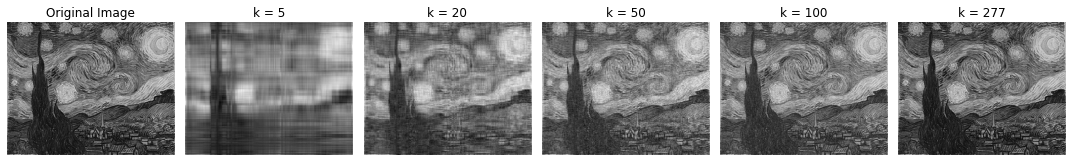

In [47]:
image = Image.open('StarryNight.jpg').convert('L')
image_matrix = np.array(image)

#  SVD durchführen mit numpy ???
U, Sigma, VT = 

# Funktion zur Rekonstruktion des Bildes mit einer gegebenen Anzahl von Singulärwerten
def reconstruct_image(U, Sigma, VT, num_singular_values): # ???
    S_reconstructed = np.zeros((num_singular_values, num_singular_values))
    np.fill_diagonal(S_reconstructed, Sigma[:num_singular_values])
    # multiplizieren Sie hier S_reconstructed mit VT mithilfe von np.dot, achten Sie hierbei dass Sie nur die Anzahl der num_singular_values verwenden
    S_Vt =
    # multiplizieren Sie hier U mit S_Vt mithilfe von np.dot, achten Sie hierbei dass Sie nur die Anzahl der num_singular_values verwenden
    U_S_Vt =
    return U_S_Vt

# Bild mit verschiedener Anzahl an singulärwerten rekonstruieren
k_values = [5, 20, 50,100,len(Sigma)]  
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(15, 6))

axes[0].imshow(image_matrix, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(U, Sigma, VT, k)
    axes[i + 1].imshow(reconstructed, cmap='gray')
    axes[i + 1].set_title(f'k = {k}')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

# Spur und Eigenwerte <a id="5"></a>

Für eine gegebene quadratische Matrix $ A $ der Größe $ n \times n $, gilt:

1. **Eigenwerte von $ A $**: Die Eigenwerte $ \lambda_1, \lambda_2, \ldots, \lambda_n $ von $ A $ sind die Lösungen der charakteristischen Gleichung $ \text{det}(A - \lambda I) = 0 $, wobei $ I $ die Einheitsmatrix ist.

2. **Spur von $ A $**: Die Spur $\text{Tr}(A)$ ist die Summe der Diagonalelemente von $ A $, also $ \text{Tr}(A) = a_{11} + a_{22} + \ldots + a_{nn} $.



### Beziehung

Die Summe der Eigenwerte von $ A $ ist gleich der Spur von $ A $. Das heißt:

$$
\lambda_1 + \lambda_2 + \ldots + \lambda_n = \text{Tr}(A)
$$

Diese Beziehung gilt unabhängig davon, ob die Eigenwerte reell oder komplex sind. Es ist wichtig zu beachten, dass dies die Summe der Eigenwerte ist, nicht notwendigerweise die Eigenwerte selbst.

Die Beziehung zwischen der Summe der Eigenwerte einer Matrix und ihrer Spur lässt sich auch durch die Eigenschaften der Determinante und der Spur im Kontext der linearen Algebra verstehen, insbesondere durch die Nutzung der Ähnlichkeit von Matrizen. Hier ist ein alternativer Weg, um diese Beziehung zu erklären:

### Jordan-Normalform

Jede quadratische Matrix $A$ kann in eine ähnliche Matrix umgeformt werden, die in ihrer Jordan-Normalform vorliegt. Das bedeutet, dass es eine invertierbare Matrix $P$ gibt, so dass $J = P^{-1}AP$ eine Jordan-Matrix ist. Die Diagonalelemente von $J$ sind die Eigenwerte von $A$, und die Spur einer Matrix bleibt bei einer Ähnlichkeitstransformation unverändert.

### Spur und Ähnlichkeitstransformation

Die Spur einer Matrix ändert sich nicht unter einer Ähnlichkeitstransformation. Das heißt, $\text{Tr}(A) = \text{Tr}(J)$. Da die Spur die Summe der Diagonalelemente ist und die Diagonalelemente von $J$ die Eigenwerte $\lambda_i$ sind, folgt, dass $\text{Tr}(A) = \lambda_1 + \lambda_2 + \ldots + \lambda_n$.

### Determinante und das charakteristische Polynom

Die Determinante von $(A - \lambda I)$ gibt das charakteristische Polynom, dessen Wurzeln die Eigenwerte sind. Die Entwicklung des charakteristischen Polynoms zeigt, dass der Term mit $\lambda^{n-1}$ durch die Spur der Matrix beeinflusst wird, was darauf hinweist, dass die lineare Summe der Eigenwerte (die Wurzeln des Polynoms) der Spur entspricht.

<div style= "color: black;background-color: powderblue ;margin: 10 px auto; padding: 10px; border-radius: 10px">
    <p style="font-size:12pt; text-align:center; color:   black; background-color: lightskyblue ;margin: 10 px auto; padding: 10px; border-radius: 10px" id="1"><b>Aufgabe 6</b>  </p> 
    
**Teilaufgabe 1:**

Implemetieren Sie die Funktion `spur(matrix)`, welche die Spur der übergebenen Matrix berechnet und diese auf Gleicheit mit der Summe der Eigenwerte der Matrix vergleicht.

**Teilaufgabe 2:**

Konstruieren Sie eine Matrix mit den Eigenwerten $\lambda_1 = 1, \lambda_2 = 5$ und $\lambda_3 = 4$ und überprüfen Sie die Matrix mit der Methode aus Teilaufgabe 1.

In [ ]:
import numpy as np

def spur(matrix):
    

A = np.array([[2, 0,0], [0, 3,0],[0,0,1]])

spur(A)